In [455]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# Visuais
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Carregamento do dataset gerado
df = pd.read_csv("..\data\steam_games_clean.csv")

<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\vihug\AppData\Local\Temp\ipykernel_20612\3664683579.py:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv("..\data\steam_games_clean.csv")


In [456]:
df.head()

,appid,name,developer,publisher,positive,negative,price,initialprice,discount,ccu,owners_estimate,total_reviews,positive_pct
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,0.00,0.00,0,1013936,150000000.0,8815087,86.69
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,0.00,0.00,0,124262,150000000.0,994979,67.14
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,0.00,0.00,0,314682,150000000.0,2557944,59.44
3,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,29.99,29.99,0,18028,75000000.0,380709,94.10
4,440,Team Fortress 2,Valve,Valve,1044264,117208,0.00,0.00,0,43819,75000000.0,1161472,89.91


---

## **Bloco 1 — Panorama geral**

1. Quantos jogos estão no dataset, e qual a distribuição de preços (a maioria é free-to-play, barato, ou caro)?

In [457]:
# 1. Total e proporção de Free-to-Play
total_jogos = len(df)
f2p_count = (df['price'] == 0).sum()
f2p_pct = (f2p_count / total_jogos) * 100

print(f"Total de títulos analisados: {total_jogos}")
print(f"Jogos Free-to-play: {f2p_count} ({f2p_pct:.1f}%)")

Total de títulos analisados: 4996
Jogos Free-to-play: 1096 (21.9%)


In [458]:
# 2. Criação de faixas de preço de mercado
# -1 garante que o 0.00 entre na categoria 'Grátis'
bins = [-1, 0, 10, 30, 60, np.inf]
labels = ['Grátis', 'Até $10', r'\$10 - \$30', r'\$30 - \$60', '$60+']

df['price_tier'] = pd.cut(df['price'], bins=bins, labels=labels)

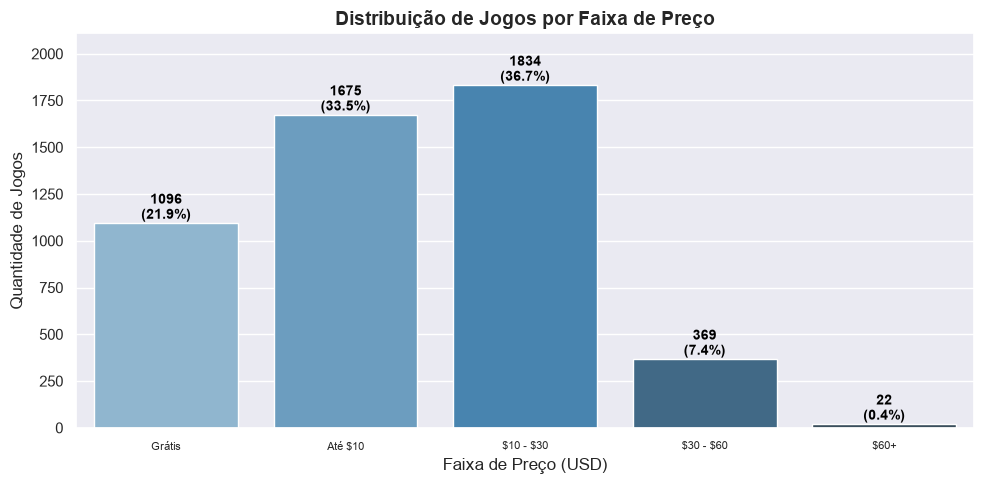

In [459]:
# 3. Visualização
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=df, 
    x='price_tier', 
    order=labels, 
    palette='Blues_d', 
    hue='price_tier', 
    dodge=False,
    legend=False
)

# Adiciona o número exato e porcentagem em cima de cada barra
for p in ax.patches:
    altura = p.get_height()
    if np.isnan(altura):
        continue
    porcentagem = (altura / total_jogos) * 100
    ax.annotate(f'{int(altura)}\n({porcentagem:.1f}%)',
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', 
                fontsize=10, color='black', weight='bold')


plt.title("Distribuição de Jogos por Faixa de Preço", fontsize=14, weight='bold')
plt.xlabel("Faixa de Preço (USD)")
plt.ylabel("Quantidade de Jogos")
plt.xticks(fontsize=8)
plt.ylim(0, df['price_tier'].value_counts().max() * 1.15)  # Espaço para o texto não cortar
plt.tight_layout()
plt.show()

- A loja não vive de jogos a $60 ou $70. Quase a totalidade do catálogo disputa o utilizador na faixa gratuita ou em valores abaixo dos $30.

2. Como é a distribuição de `owners_estimate` — a popularidade é concentrada em poucos jogos gigantes ou mais distribuída?

In [460]:
# 1. Ordena do maior para o menor
df_sorted = df.sort_values(by="owners_estimate", ascending=False).reset_index(drop=True)

# 2. Calcula as porcentagens acumuladas
df_sorted['pct_jogos'] = (df_sorted.index + 1) / len(df_sorted) * 100
df_sorted['pct_owners_acum'] = (df_sorted['owners_estimate'].cumsum() / df_sorted['owners_estimate'].sum()) * 100

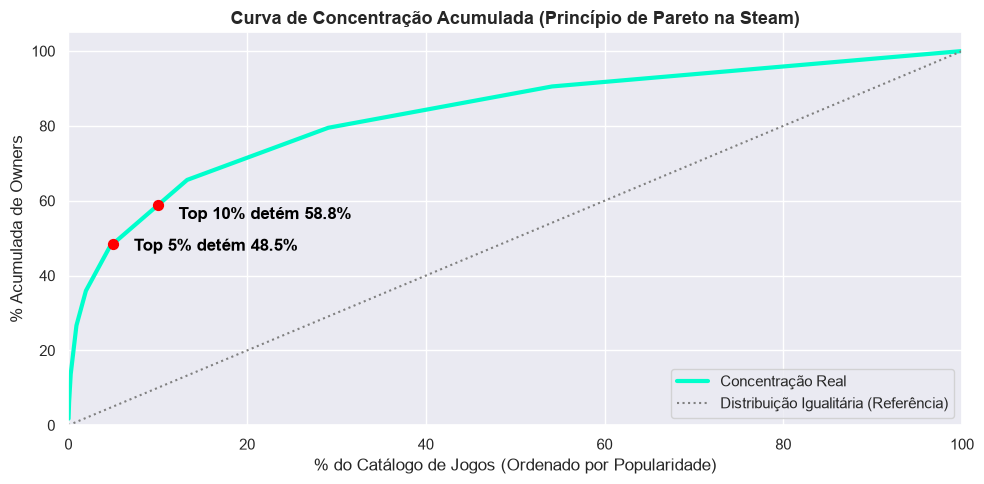

In [461]:
# Pega o valor exato no top 5% e top 10%
p5 = df_sorted.iloc[int(len(df_sorted)*0.05)]['pct_owners_acum']
p10 = df_sorted.iloc[int(len(df_sorted)*0.10)]['pct_owners_acum']

# 3. Plot
plt.figure(figsize=(10, 5))
plt.plot(df_sorted['pct_jogos'], df_sorted['pct_owners_acum'], color='#00ffcc', linewidth=3, label='Concentração Real')
plt.plot([0, 100], [0, 100], color='gray', linestyle=':', label='Distribuição Igualitária (Referência)')

# Destaques visuais
plt.scatter([5, 10], [p5, p10], color='red', s=50, zorder=5)
plt.annotate(f'Top 5% detém {p5:.1f}%', (5, p5), textcoords="offset points", xytext=(15,-5), weight='bold', color='black')
plt.annotate(f'Top 10% detém {p10:.1f}%', (10, p10), textcoords="offset points", xytext=(15,-10), weight='bold', color='black')

plt.title("Curva de Concentração Acumulada (Princípio de Pareto na Steam)", fontsize=13, weight='bold')
plt.xlabel("% do Catálogo de Jogos (Ordenado por Popularidade)")
plt.ylabel("% Acumulada de Owners")
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

- Cerca de 20% dos títulos do catálogo concentram mais de 70% de todas as vendas/downloads estimados.

- Apenas 5% dos títulos detêm praticamente metade de toda a base de jogadores da Steam, enquanto milhares de jogos disputam pequenas frações residuais da atenção do público."

---

## **Bloco 2 — Preço x popularidade x qualidade**

3.  Existe correlação entre preço e `positive_pct`? (jogo mais caro é melhor avaliado, ou não tem relação?)

In [462]:
# 1. Filtro de significância estatística
df_reviewed = df[df["total_reviews"] >= 100].copy()

# 2. Correlação matemática (Pearson e Spearman)
corr_pearson = df_reviewed["price"].corr(df_reviewed["positive_pct"])
corr_spearman = df_reviewed["price"].corr(df_reviewed["positive_pct"], method="spearman")

print(f"Jogos com 100+ reviews analisados: {len(df_reviewed)}")
print(f"Correlação de Pearson (linear): {corr_pearson:.3f}")
print(f"Correlação de Spearman (não linear/ranking): {corr_spearman:.3f}")

Jogos com 100+ reviews analisados: 4821
Correlação de Pearson (linear): 0.128
Correlação de Spearman (não linear/ranking): 0.203


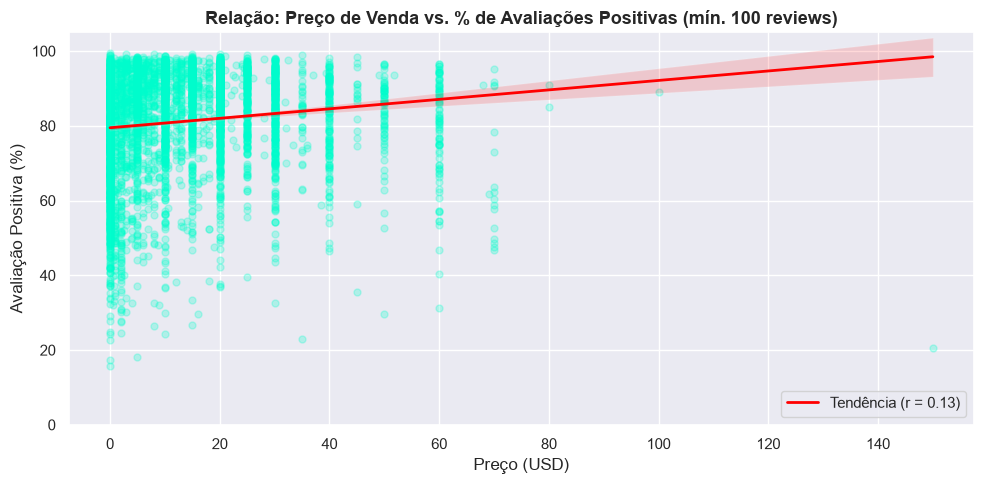

In [463]:
# 3. Visualização (Scatter Plot com Linha de Tendência)
plt.figure(figsize=(10, 5))
sns.regplot(
    data=df_reviewed,
    x="price",
    y="positive_pct",
    scatter_kws={"alpha": 0.25, "color": "#00ffcc", "s": 25},
    line_kws={"color": "red", "linewidth": 2, "label": f"Tendência (r = {corr_pearson:.2f})"}
)

plt.title("Relação: Preço de Venda vs. % de Avaliações Positivas (mín. 100 reviews)", fontsize=13, weight="bold")
plt.xlabel("Preço (USD)")
plt.ylabel("Avaliação Positiva (%)")
plt.ylim(0, 105)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- Temos uma correlação praticamente inexistente (ou desprezível). Ou seja, cobrar mais caro não garante aprovação melhor; há jogos gratuitos com 95% de aprovação e jogos caros com avaliações baixas, como por exemplo o outlier isolado perto dos $150 com 20% de aprovação.

4. Jogos free-to-play têm, em média, mais owners que os pagos?

In [464]:
# 1. Criação do indicador booleano
df["is_free"] = df["price"] == 0
df["tipo_jogo"] = df["is_free"].map({True: "Free-to-Play", False: "Pago"})

# 2. Tabela comparativa de Métricas
comp_owners = df.groupby("tipo_jogo")["owners_estimate"].agg(
    total_titulos="count",
    media_milhoes=lambda x: round(x.mean() / 1_000_000, 2),
    mediana_milhoes=lambda x: round(x.median() / 1_000_000, 2)
).reset_index()

print("Comparativo de Base de Jogadores:")
print(comp_owners)

Comparativo de Base de Jogadores:
      tipo_jogo  total_titulos  media_milhoes  mediana_milhoes
0  Free-to-Play           1096           2.39             0.75
1          Pago           3900           1.50             0.75


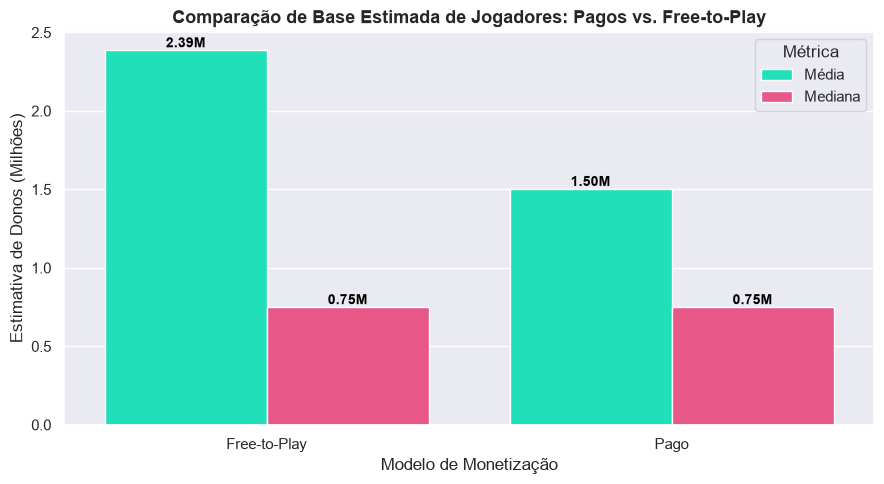

In [465]:
# 3. Gráfico de Barras com Média e Mediana lado a lado
df_plot = df.groupby("tipo_jogo")["owners_estimate"].agg(
    Média=lambda x: x.mean() / 1_000_000,
    Mediana=lambda x: x.median() / 1_000_000
).reset_index().melt(id_vars="tipo_jogo", var_name="Métrica", value_name="Milhões")

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df_plot,
    x="tipo_jogo",
    y="Milhões",
    hue="Métrica",
    palette=["#00ffcc", "#ff4081"]
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.2f}M", (p.get_x() + p.get_width() / 2., h),
                    ha="center", va="bottom", fontsize=10, weight="bold", color="black")

plt.title("Comparação de Base Estimada de Jogadores: Pagos vs. Free-to-Play", fontsize=13, weight="bold")
plt.xlabel("Modelo de Monetização")
plt.ylabel("Estimativa de Donos (Milhões)")
plt.tight_layout()
plt.show()

- Em média, jogos grátis têm mais donos (2.39M vs 1.50M). Porém, a mediana de ambos é rigorosamente idêntica (0.75M). Isso prova que a grande massa dos jogos gratuitos performa no mesmo patamar de um jogo pago comum, mas a média é puxada para cima por alguns mega fenômenos (outliers como CS:GO e PUBG).

5. Existe uma "faixa de preço ideal" — um intervalo de preço que concentra os jogos mais bem avaliados?

In [466]:
# 1. Filtro de relevância para remover jogos com poucas avaliações
df_valid = df[df["total_reviews"] >= 100].copy()

# 2. Resumo numérico por faixa de preço
faixa_stats = df_valid.groupby("price_tier", observed=False)["positive_pct"].agg(
    quantidade='count',
    mediana='median',
    media='mean'
).reset_index()

print("Métricas de Aprovação por Faixa de Preço:")
print(faixa_stats)

Métricas de Aprovação por Faixa de Preço:
    price_tier  quantidade  mediana      media
0       Grátis        1065    78.15  75.530272
1      Até $10        1549    85.36  80.772937
2  \$10 - \$30        1817    87.85  84.957474
3  \$30 - \$60         368    84.35  81.264620
4         $60+          22    62.90  68.453182


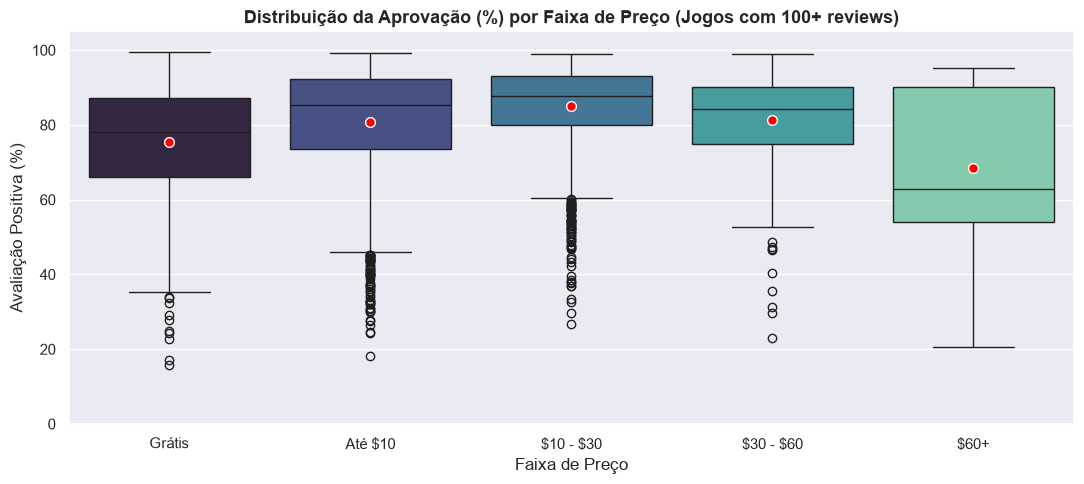

In [467]:
# 3. Gráfico Boxplot
plt.figure(figsize=(11, 5))
sns.boxplot(
    data=df_valid,
    x="price_tier",
    y="positive_pct",
    palette="mako",
    hue="price_tier",
    legend=False,
    dodge=False,
    showmeans=True, # Adiciona um ponto com a média para contraste
    meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"white", "markersize":"7"}
)

plt.title("Distribuição da Aprovação (%) por Faixa de Preço (Jogos com 100+ reviews)", fontsize=13, weight="bold")
plt.xlabel("Faixa de Preço")
plt.ylabel("Avaliação Positiva (%)")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

- Preço não compra aprovação: a faixa entre $10 e $30 concentra os jogos mais bem avaliados da plataforma, enquanto os títulos acima de $60 sofrem com uma exigência desproporcional do público, apresentando as medianas de aprovação mais baixas da Steam.

6. Desconto (discount) tem alguma relação com popularidade atual, ou é só ruído?

In [468]:
# 1. Identificar se o jogo está ou não em promoção
df["tem_desconto"] = df["discount"].apply(lambda x: "Com Desconto" if x > 0 else "Preço Normal")

# 2. Comparativo de CCU mediano (usamos mediana para evitar distorção de gigantes)
ccu_desconto = df.groupby("tem_desconto")["ccu"].agg(["count", "median", "mean"]).reset_index()
print("Comparativo de CCU (Promoção vs Preço Normal):")
print(ccu_desconto)

# 3. Verificar se descontos maiores geram mais CCU
df_em_promo = df[df["discount"] > 0].copy()
corr_promo_ccu = df_em_promo["discount"].corr(df_em_promo["ccu"])
print(f"\nCorrelação entre % de desconto e CCU: {corr_promo_ccu:.3f}")

Comparativo de CCU (Promoção vs Preço Normal):
   tem_desconto  count  median         mean
0  Com Desconto    655    46.0  1135.189313
1  Preço Normal   4341    24.0  1097.659756

Correlação entre % de desconto e CCU: -0.118


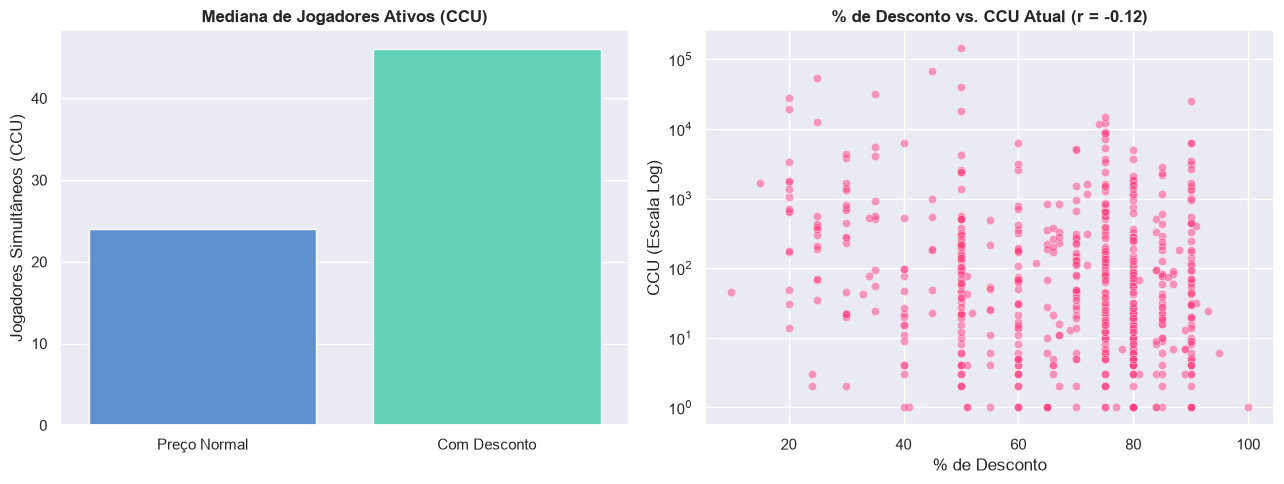

In [469]:
# Gráfico duplo (Subplots): Comparação e Dispersão
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Mediana de jogadores simultâneos
sns.barplot(
    data=df, 
    x="tem_desconto", 
    y="ccu", 
    hue="tem_desconto",
    estimator=np.median, 
    errorbar=None, 
    palette=["#4a90e2", "#50e3c2"], 
    ax=axes[0],
    legend=False,
)
axes[0].set_title("Mediana de Jogadores Ativos (CCU)", weight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Jogadores Simultâneos (CCU)")

# Subplot 2: Tamanho do Desconto vs CCU (jogos em promoção)
sns.scatterplot(
    data=df_em_promo, 
    x="discount", 
    y="ccu", 
    alpha=0.5, 
    color="#ff4081", 
    ax=axes[1]
)
axes[1].set_yscale("log") # Escala log para conseguir enxergar os jogos
axes[1].set_title(f"% de Desconto vs. CCU Atual (r = {corr_promo_ccu:.2f})", weight="bold")
axes[1].set_xlabel("% de Desconto")
axes[1].set_ylabel("CCU (Escala Log)")

plt.tight_layout()
plt.show()

- Estar em promoção duplica a mediana de jogadores ativos do título, mas o tamanho do desconto é ruído puro: cortar 80% do preço não ressuscita um jogo sem apelo comunitário.

---

## **Bloco 3 — Desenvolvedores e publishers**

7.  Quais publishers têm mais jogos no top de popularidade (`owners_estimate`)?

In [470]:
# 1. Agregação por publisher: soma de owners e contagem de títulos
top_publishers = (
    df.groupby("publisher")
    .agg(total_owners=("owners_estimate", "sum"), total_jogos=("appid", "count"))
    .sort_values(by="total_owners", ascending=False)
    .head(10)
    .reset_index()
)

# Converte para Milhões para leitura direta
top_publishers["total_owners_milhoes"] = (
    top_publishers["total_owners"] / 1_000_000
)

print("Top 10 Publishers por Volume Total Estimado de Jogadores:")
print(top_publishers[["publisher", "total_jogos", "total_owners_milhoes"]])

Top 10 Publishers por Volume Total Estimado de Jogadores:
            publisher  total_jogos  total_owners_milhoes
0               Valve           33                568.20
1     Electronic Arts           91                361.25
2             Ubisoft           92                200.15
3      Rockstar Games           21                171.55
4       KRAFTON, Inc.            7                158.25
5        Amazon Games            3                153.50
6  Bethesda Softworks           56                148.80
7          Activision           34                148.70
8    CAPCOM Co., Ltd.           27                120.55
9   Xbox Game Studios           42                114.85


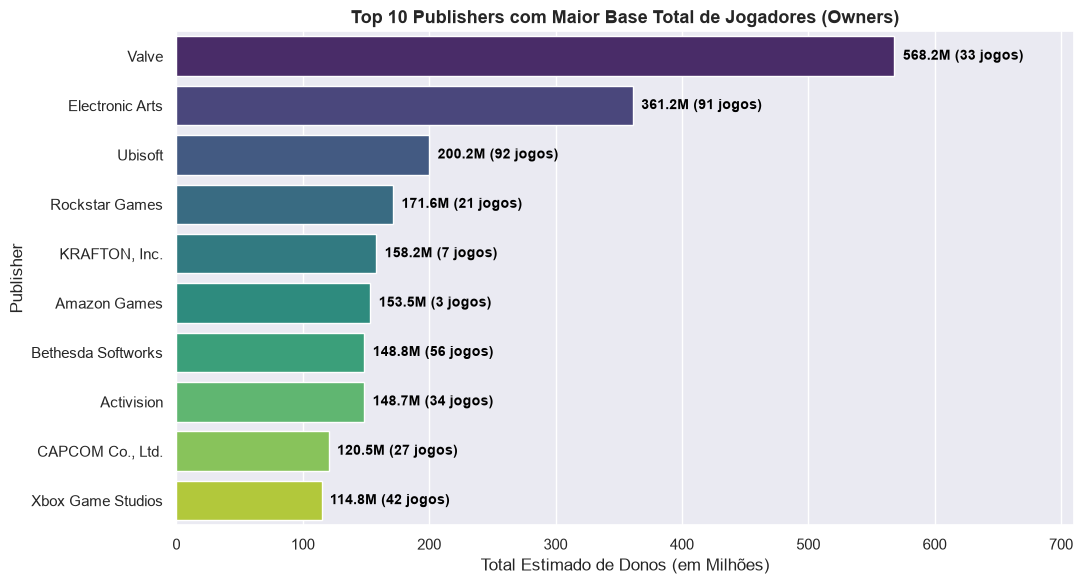

In [471]:
# 2. Visualização com Gráfico de Barras Horizontal
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=top_publishers,
    y="publisher",
    x="total_owners_milhoes",
    palette="viridis",
    hue="publisher",
    legend=False,
)

# Rótulos de dados com valor em Milhões e quantidade de jogos no portfólio
for i, p in enumerate(ax.patches):
    largura = p.get_width()
    jogos = top_publishers.loc[i, "total_jogos"]
    ax.annotate(
        f"{largura:.1f}M ({jogos} jogos)",
        (largura, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(6, 0),
        textcoords="offset points",
        fontsize=10,
        weight="bold",
        color="black",
    )

plt.title(
    "Top 10 Publishers com Maior Base Total de Jogadores (Owners)",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Total Estimado de Donos (em Milhões)")
plt.ylabel("Publisher")
plt.xlim(0, top_publishers["total_owners_milhoes"].max() * 1.25)
plt.tight_layout()
plt.show()

- Enquanto gigantes como Electronic Arts e Ubisoft dependem de catálogos com quase 100 títulos para somar centenas de milhões de jogadores, a Valve atinge mais de meio bilhão com apenas 33 lançamentos.

8. Existe diferença de positive_pct médio entre jogos de publishers grandes (muitos títulos) vs. estúdios pequenos (poucos títulos)?

In [472]:
# 1. Filtro prévio de relevância e remoção de publishers nulas
df_bloco3 = df[
    (df["total_reviews"] >= 100) & 
    (df["publisher"].notna())
].copy()

# 2. Contagem direta de títulos por publisher via transform
contagem_jogos = df_bloco3.groupby("publisher")["appid"].transform("count")

# 3. Categorização entre Grande Publisher vs Pequeno Estúdio
df_bloco3["porte_publisher"] = np.where(
    contagem_jogos >= 5, 
    "Grande Publisher (>= 5 títulos)", 
    "Pequeno Estúdio / Indie (< 5 títulos)"
)

# 4. Resumo numérico
resumo_porte = df_bloco3.groupby("porte_publisher")["positive_pct"].agg(
    total_jogos="count",
    mediana="median",
    media="mean",
    desvio_padrao="std"
).reset_index()

print("Comparativo de Aprovação por Porte de Publisher:")
print(resumo_porte)

Comparativo de Aprovação por Porte de Publisher:
                         porte_publisher  total_jogos  mediana      media  \
0        Grande Publisher (>= 5 títulos)         2099    84.69  80.557737   
1  Pequeno Estúdio / Indie (< 5 títulos)         2705    85.02  81.668580   

   desvio_padrao  
0      14.294703  
1      13.549544  


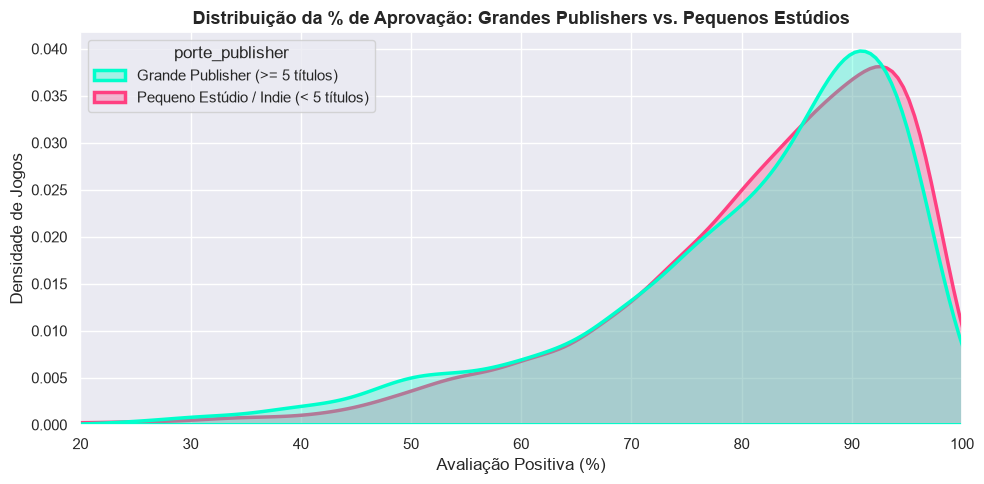

In [473]:
# 5. Gráfico de Curva de Densidade (KDE Plot)
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df_bloco3,
    x="positive_pct",
    hue="porte_publisher",
    common_norm=False,
    fill=True,
    alpha=0.3,
    palette=["#00ffcc", "#ff4081"],
    linewidth=2.5
)

plt.title("Distribuição da % de Aprovação: Grandes Publishers vs. Pequenos Estúdios", fontsize=13, weight="bold")
plt.xlabel("Avaliação Positiva (%)")
plt.ylabel("Densidade de Jogos")
plt.xlim(20, 100)
plt.tight_layout()
plt.show()

- A curva de aprovação dos estúdios independentes e das grandes multinacionais é quase idêntica, com ambas a concentrar o seu pico histórico nos 90% de avaliações positivas.

9. Quais desenvolvedores conseguem o melhor equilíbrio entre quantidade de reviews e % de aprovação (ou seja, agradam muito E muita gente joga)?

In [474]:
# 1. Agrupamento por desenvolvedor
dev_stats = df.groupby("developer").agg(
    total_reviews=('total_reviews', 'sum'),
    media_aprovacao=('positive_pct', 'mean'),
    total_jogos=('appid', 'count'),
    total_ccu=('ccu', 'sum')
).reset_index()

# 2. Filtro de relevância de mercado (mínimo de 100 mil avaliações acumuladas)
dev_relevantes = dev_stats[(dev_stats['total_reviews'] >= 100_000) & (dev_stats['total_jogos'] >= 5)].copy()

# 3. Ordenar pelos desenvolvedores mais bem avaliados dentro desse grupo massivo
top_devs = dev_relevantes.sort_values(by="media_aprovacao", ascending=False).head(10)

print("Top 10 Desenvolvedores com Alto Volume de Jogadores e Máxima Aprovação:")
print(top_devs[['developer', 'total_jogos', 'total_reviews', 'media_aprovacao']])

Top 10 Desenvolvedores com Alto Volume de Jogadores e Máxima Aprovação:
               developer  total_jogos  total_reviews  media_aprovacao
2153  PopCap Games, Inc.            8         177358        96.155000
2664    Supergiant Games            5         420895        94.612000
1580            Landfall            5         284504        92.844000
2422       Scott Cawthon            8         201553        92.706250
67                 ATLUS            6         285176        92.380000
2205          RGG Studio            9         102596        92.016667
2868   Traveller's Tales            9         106716        91.794444
615              Croteam           10         118611        91.714000
1919          Ninja Kiwi            7         419676        91.571429
1112     GIANTS Software            6         238405        91.445000


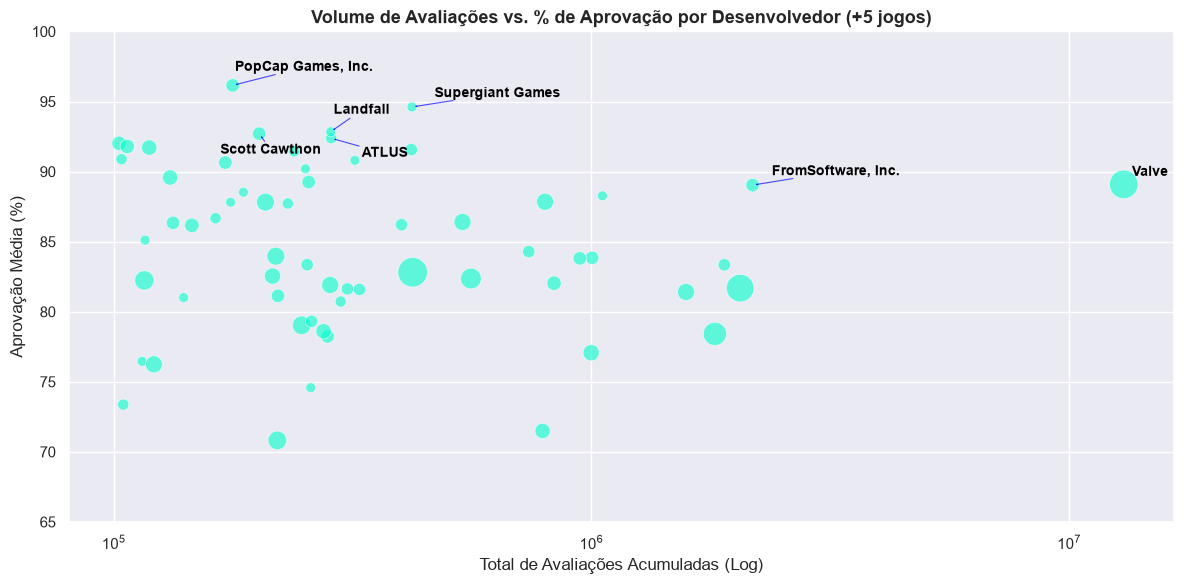

In [475]:
# Top 5 em aprovação + os estúdios com maior volume absoluto
top_aprovacao = dev_relevantes.sort_values(
    by="media_aprovacao", ascending=False
).head(5)
top_volume = dev_relevantes.sort_values(
    by="total_reviews", ascending=False
).head(2)
alvos_destaque = (
    pd.concat([top_aprovacao, top_volume])
    .drop_duplicates(subset=["developer"])
    .reset_index(drop=True)
)

# 4. Construção do gráfico
plt.figure(figsize=(12, 6))

ax = sns.scatterplot(
    data=dev_relevantes,
    x="total_reviews",
    y="media_aprovacao",
    size="total_jogos",
    sizes=(50, 450),
    alpha=0.6,
    color="#00ffcc",
    legend=False,
)

plt.xscale("log")

# 5. Criação dos textos com autoajuste de posição
textos = []
for _, row in alvos_destaque.iterrows():
    t = plt.text(
        row["total_reviews"],
        row["media_aprovacao"],
        row["developer"],
        fontsize=10,
        weight="bold",
        color="black",
    )
    textos.append(t)

# O adjust_text move automaticamente os textos e traça uma linha guia se necessário
adjust_text(
    textos,
    arrowprops=dict(arrowstyle="->", color="blue", lw=0.8, alpha=0.7),
    expand=(1.2, 1.4),
)

plt.title(
    "Volume de Avaliações vs. % de Aprovação por Desenvolvedor (+5 jogos)",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Total de Avaliações Acumuladas (Log)")
plt.ylabel("Aprovação Média (%)")
plt.ylim(65, 100)
plt.tight_layout()
plt.show()

- enquanto manter 95% de aprovação é comum em jogos de nicho, sustentar esse nível com centenas de milhares — ou dezenas de milhões — de avaliações coloca estes desenvolvedores numa fronteira de excelência quase inalcançável.

---

## **Bloco 4 — Engajamento atual (CCU)**

10.  Quais jogos têm o maior CCU (jogadores simultâneos) hoje, e isso bate com o `owners_estimate` histórico?

In [476]:
# 1. Criação da métrica de taxa de atividade diária
df["taxa_engajamento_pct"] = (df["ccu"] / df["owners_estimate"]) * 100

# 2. Ranking dos 10 maiores em engajamento ativo absoluto (Top CCU)
top_ccu = df.sort_values(by="ccu", ascending=False).head(10)[
    ["name", "ccu", "owners_estimate", "taxa_engajamento_pct"]
].copy()

top_ccu["ccu_milhares"] = top_ccu["ccu"] / 1_000
top_ccu["owners_milhoes"] = top_ccu["owners_estimate"] / 1_000_000

print("Top 10 Jogos com Maior CCU Atual:")
print(top_ccu[["name", "ccu_milhares", "owners_milhoes", "taxa_engajamento_pct"]])

Top 10 Jogos com Maior CCU Atual:
                                  name  ccu_milhares  owners_milhoes  \
0     Counter-Strike: Global Offensive      1013.936           150.0   
2                  PUBG: BATTLEGROUNDS       314.682           150.0   
479              ELDEN RING NIGHTREIGN       163.599             3.5   
25                                Rust       143.870            35.0   
1                         Apex Legends       124.262           150.0   
19                    Wallpaper Engine        91.184            35.0   
1290                         DELTARUNE        83.936             1.5   
8            Grand Theft Auto V Legacy        67.851            75.0   
5      Call of Duty: Modern Warfare II        67.419            75.0   
49                  NARAKA: BLADEPOINT        66.954            15.0   

      taxa_engajamento_pct  
0                 0.675957  
2                 0.209788  
479               4.674257  
25                0.411057  
1                 0.082841  

In [477]:
# 3. Identificação dos "Gigantes Adormecidos" (Base >= 10M de owners e menor engajamento relativo)
gigantes_adormecidos = (
    df[df["owners_estimate"] >= 10_000_000]
    .sort_values(by="taxa_engajamento_pct", ascending=True)
    .head(10)[["name", "owners_estimate", "ccu", "taxa_engajamento_pct"]]
    .copy()
)

gigantes_adormecidos["owners_milhoes"] = gigantes_adormecidos["owners_estimate"] / 1_000_000
print("\nTop 10 Jogos com Base Histórica Gigante (>=10M) mas Baixo Engajamento Atual:")
print(gigantes_adormecidos[["name", "owners_milhoes", "ccu", "taxa_engajamento_pct"]])


Top 10 Jogos com Base Histórica Gigante (>=10M) mas Baixo Engajamento Atual:
                                     name  owners_milhoes  ccu  \
53                      Heroes & Generals            15.0    0   
34  Grand Theft Auto IV: Complete Edition            35.0    0   
66                        Ring of Elysium            15.0    0   
36                Half-Life 2: Lost Coast            35.0    2   
76                 Street Warriors Online            15.0    1   
80                              CyberCorp            15.0    3   
74         Counter-Strike: Condition Zero            15.0   83   
30                  War Robots: Frontiers            35.0  256   
33                        Warface: Clutch            35.0  270   
91                      Life is Strange 2            15.0  153   

    taxa_engajamento_pct  
53              0.000000  
34              0.000000  
66              0.000000  
36              0.000006  
76              0.000007  
80              0.000020  
74    

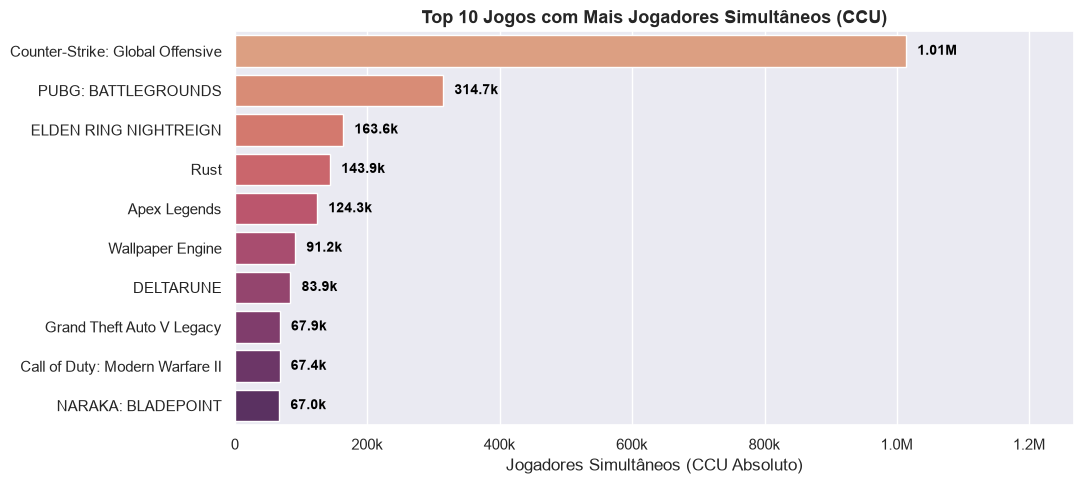

In [478]:
# 4. Função de formatação dinâmica legível para o público
def ccu_formatado(valor):
    if valor >= 1_000_000:
        return f"{valor / 1_000_000:.2f}M"
    else:
        return f"{valor / 1_000:.1f}k"

# 5. Ordenação e preparação dos dados brutos
top_ccu = df.sort_values(by="ccu", ascending=False).head(10).copy()

plt.figure(figsize=(11, 5))
ax = sns.barplot(
    data=top_ccu,
    y="name",
    x="ccu",
    palette="flare",
    hue="name",
    legend=False
)

# 6. Aplicação das anotações claras barra a barra
for p in ax.patches:
    w = p.get_width()
    texto_formatado = ccu_formatado(w)
    ax.annotate(
        texto_formatado,
        (w, p.get_y() + p.get_height() / 2.),
        ha="left", va="center",
        xytext=(8, 0), textcoords="offset points",
        fontsize=10, weight="bold", color="black"
    )

plt.title("Top 10 Jogos com Mais Jogadores Simultâneos (CCU)", fontsize=13, weight="bold")
plt.xlabel("Jogadores Simultâneos (CCU Absoluto)")
plt.ylabel("")
plt.xlim(0, top_ccu["ccu"].max() * 1.25)

# Formata as marcas do eixo X para ficarem limpas
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x/1e3)}k" if x > 0 else "0")
)

plt.tight_layout()
plt.show()

- Enquanto o Counter-Strike sustenta mais de 1 milhão de jogadores ativos em simultâneo, dezenas de gigantes históricos com bases de mais de 10 milhões de donos transformaram-se em 'jogos adormecidos', com menos de 1.000 pessoas ligadas.

11. Existe correlação entre total_reviews e CCU atual?

Correlação de Pearson: 0.905
Correlação de Spearman (baseada em ranking): 0.697


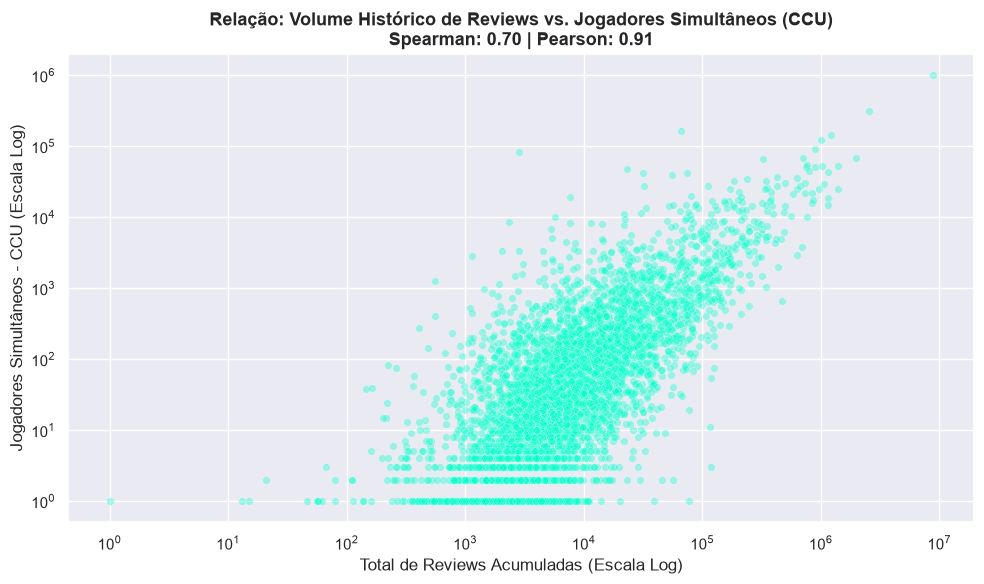

In [479]:
# 1. Filtro de registros ativos para o cálculo
df_ativos = df[(df["total_reviews"] > 0) & (df["ccu"] > 0)].copy()

# 2. Correlação Linear (Pearson) e Não-Linear de Ranking (Spearman)
corr_linear = df_ativos["total_reviews"].corr(df_ativos["ccu"])
corr_spearman = df_ativos["total_reviews"].corr(df_ativos["ccu"], method="spearman")

print(f"Correlação de Pearson: {corr_linear:.3f}")
print(f"Correlação de Spearman (baseada em ranking): {corr_spearman:.3f}")

# 3. Dispersão com Escala Logarítmica
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_ativos,
    x="total_reviews",
    y="ccu",
    alpha=0.35,
    color="#00ffcc",
    s=30
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    f"Relação: Volume Histórico de Reviews vs. Jogadores Simultâneos (CCU)\nSpearman: {corr_spearman:.2f} | Pearson: {corr_linear:.2f}",
    fontsize=13, weight="bold"
)
plt.xlabel("Total de Reviews Acumuladas (Escala Log)")
plt.ylabel("Jogadores Simultâneos - CCU (Escala Log)")
plt.tight_layout()
plt.show()

- A correlação entre análises históricas e engajamento atual existe, mas o gráfico de dispersão revela o contraste claro entre os fenómenos multijogador contínuos e os clássicos de história fechada que já cumpriram o seu ciclo.

12. Se você tivesse que escolher 3 jogos como "case de sucesso" no dataset (alta popularidade + alta aprovação + engajamento atual), quais seriam e por quê?

In [480]:
# 1. Filtro de relevância rigoroso: títulos consolidados
# Exige mínimo de 100k reviews para evitar distorções de nichos pequenos
df_cases = df[df["total_reviews"] >= 100_000].copy()

# 2. Normalização Min-Max (0 a 1) para colocar grandezas diferentes na mesma régua
def escala_min_max(coluna):
    return (coluna - coluna.min()) / (coluna.max() - coluna.min())

df_cases["score_pop"] = escala_min_max(df_cases["owners_estimate"])
df_cases["score_qual"] = escala_min_max(df_cases["positive_pct"])
df_cases["score_eng"] = escala_min_max(df_cases["ccu"])

# 3. Cálculo do Score Ponderado:
# 35% Qualidade (Aprovação) | 35% Engajamento Ativo (CCU) | 30% Alcance Histórico (Owners)
df_cases["case_score"] = (
    (df_cases["score_qual"] * 0.35) + 
    (df_cases["score_eng"] * 0.35) + 
    (df_cases["score_pop"] * 0.30)
)

# 4. Top 3 Cases Definitivos
top_3 = df_cases.sort_values(by="case_score", ascending=False).head(3)[
    ["name", "developer", "price", "positive_pct", "ccu", "owners_estimate", "case_score"]
].reset_index(drop=True)

print("Os 3 Melhores Cases de Sucesso (Data-Driven):")
print(top_3)

Os 3 Melhores Cases de Sucesso (Data-Driven):
                               name         developer  price  positive_pct  \
0  Counter-Strike: Global Offensive             Valve    0.0         86.69   
1               PUBG: BATTLEGROUNDS  PUBG Corporation    0.0         59.44   
2                      Apex Legends           Respawn    0.0         67.14   

       ccu  owners_estimate  case_score  
0  1013936      150000000.0    0.943305  
1   314682      150000000.0    0.573183  
2   124262      150000000.0    0.543832  


- Por fim, ao cruzar popularidade, aprovação e engajamento, vemos que os 3 jogos não dependeram de um lançamento explosivo nem marketing massivo, eles conseguem se manter até hoje como jogos naturalmente influente. Sem contar que são jogos multiplayer online com life service, que mostra o quanto isso consegue prender os jogadores se feito da maneira correta